<a href="https://colab.research.google.com/github/AhmadKevin000/machineLearning/blob/main/week04ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Praktikum 1**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
# Seleksi Fitur

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

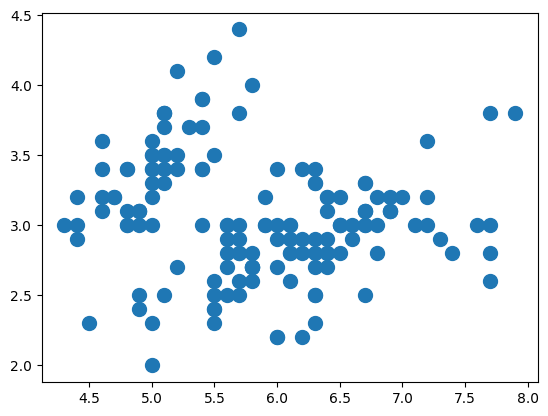

In [4]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

In [8]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

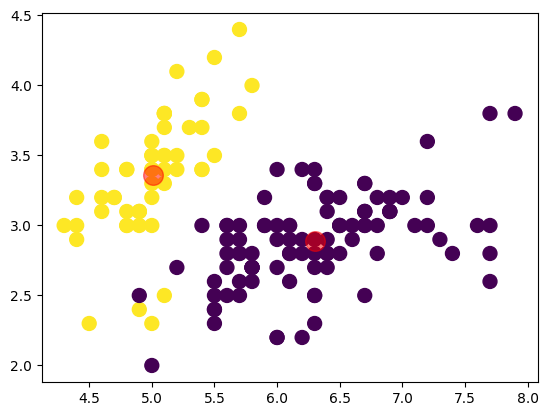

In [9]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [10]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


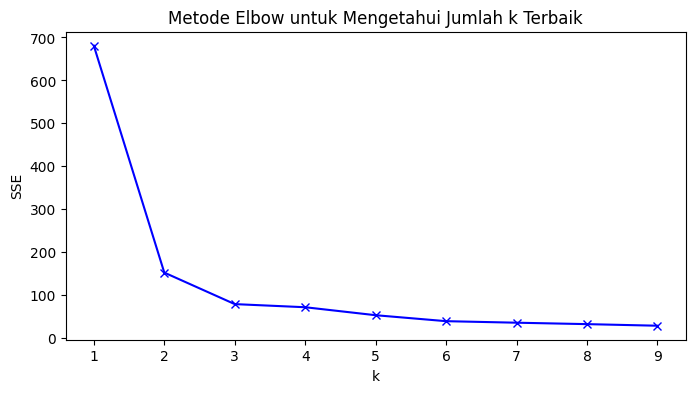

In [13]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [14]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94506582597728
k=4; SSE=71.66131466733202
k=5; SSE=53.08275416666666
k=6; SSE=39.19708292889162
k=7; SSE=35.628799358974355
k=8; SSE=32.30745238095238
k=9; SSE=28.601745984384095


**Praktikum 2**

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

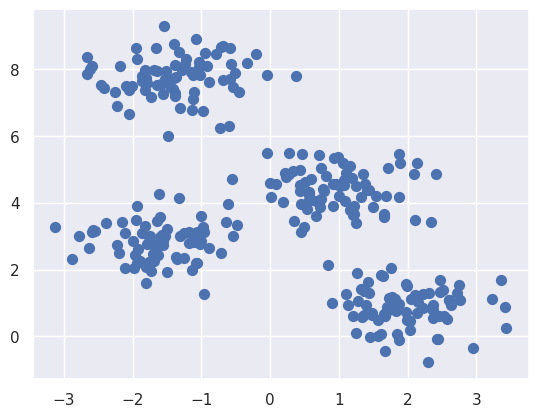

In [16]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [17]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

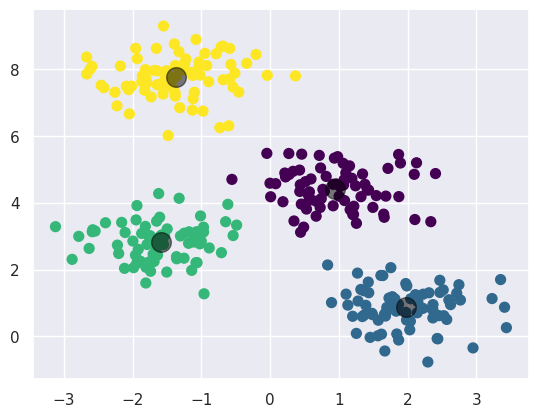

In [18]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

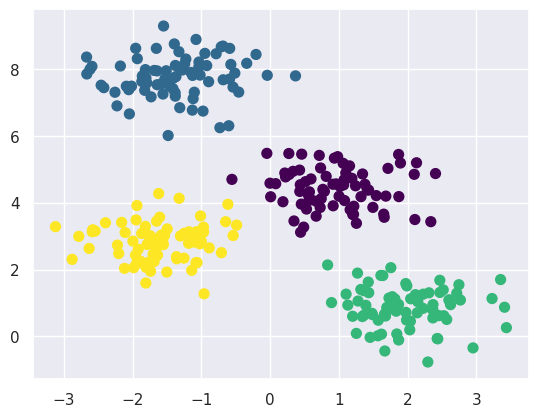

In [19]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

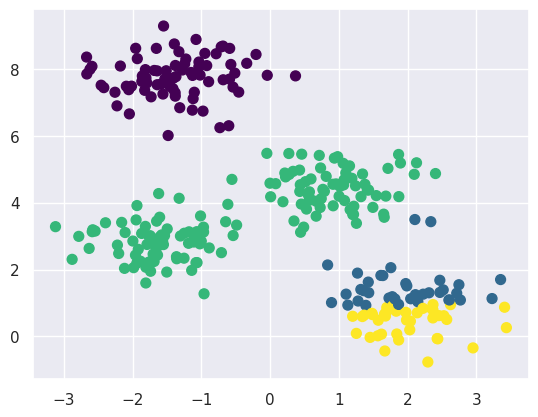

In [20]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

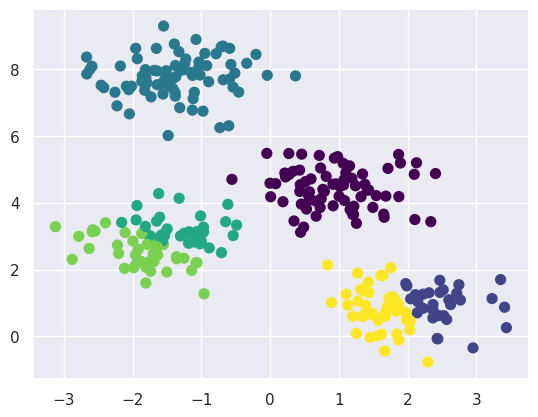

In [21]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

In [22]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

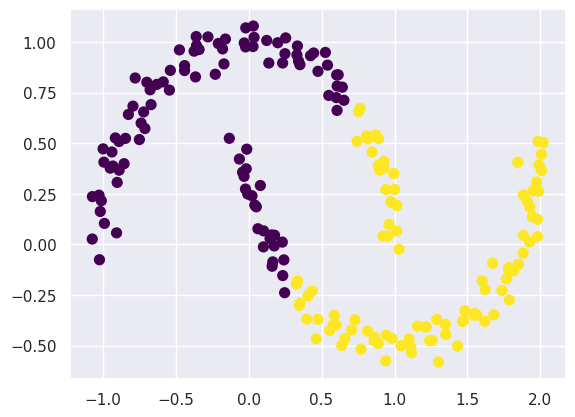

In [23]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


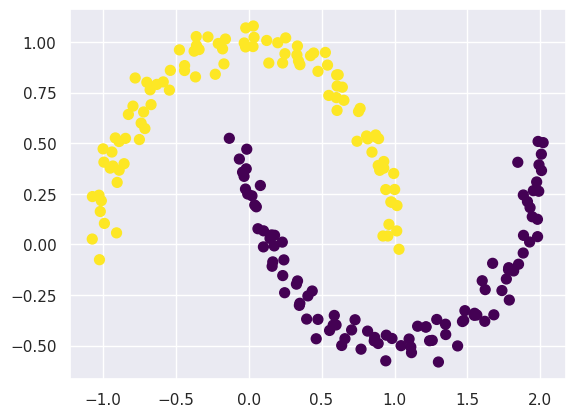

In [24]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

In [26]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [27]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

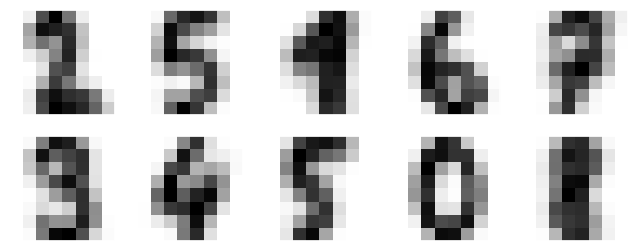

In [28]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [29]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [30]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

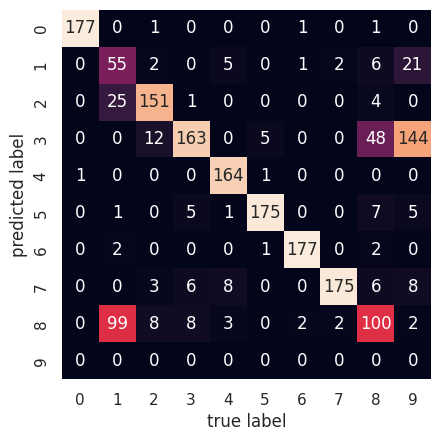

In [31]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [32]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

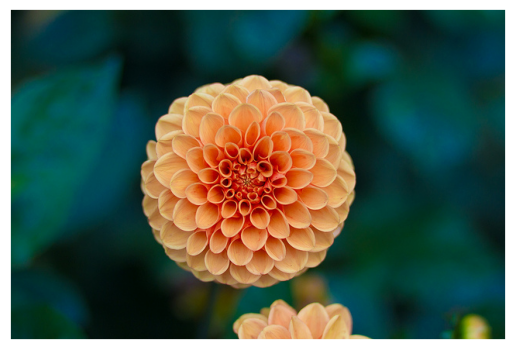

In [33]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [34]:
flower.shape

(427, 640, 3)

In [35]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [36]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

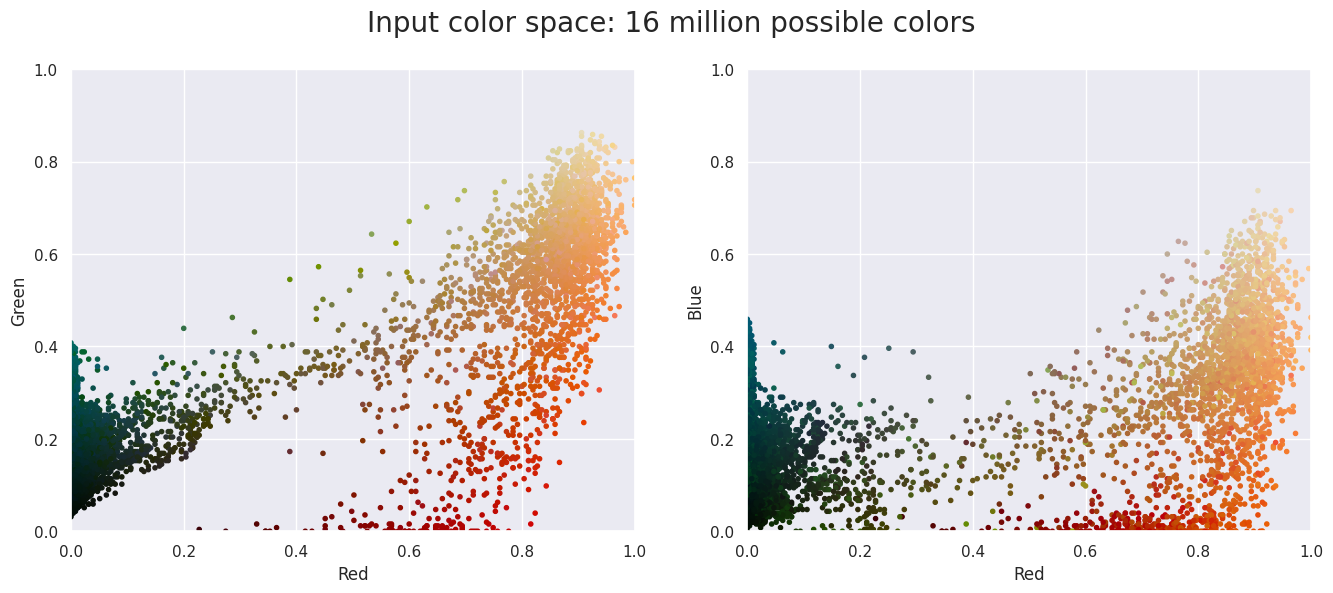

In [37]:
plot_pixels(data, title='Input color space: 16 million possible colors')

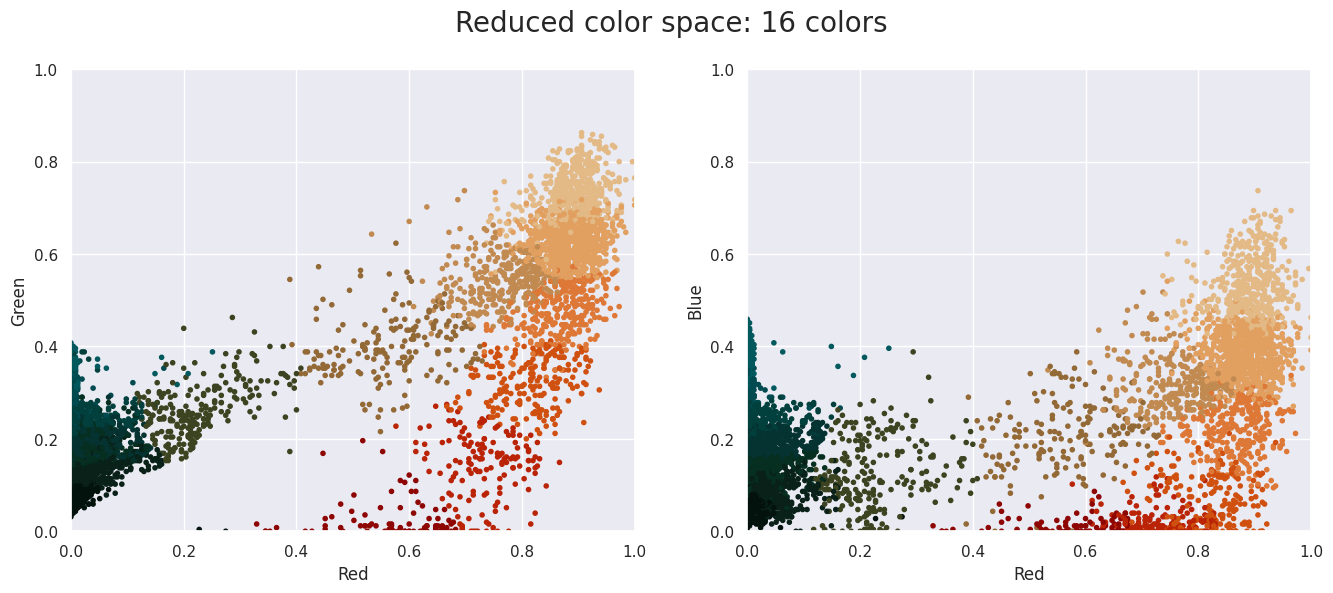

In [38]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

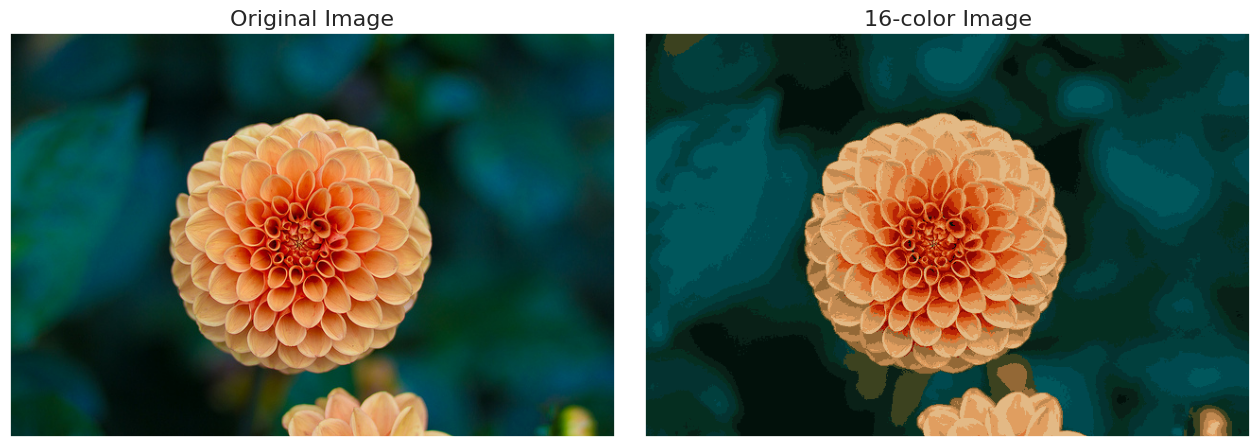

In [39]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

**Praktikum 3**

In [41]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

In [73]:
import matplotlib.pyplot as plt

(X[:, 0], X[:, 1])
()

InvalidIndexError: (slice(None, None, None), 0)

In [44]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


In [46]:
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score, adjusted_rand_score, adjusted_mutual_info_score, silhouette_score

print(f"Homogeneity: {homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


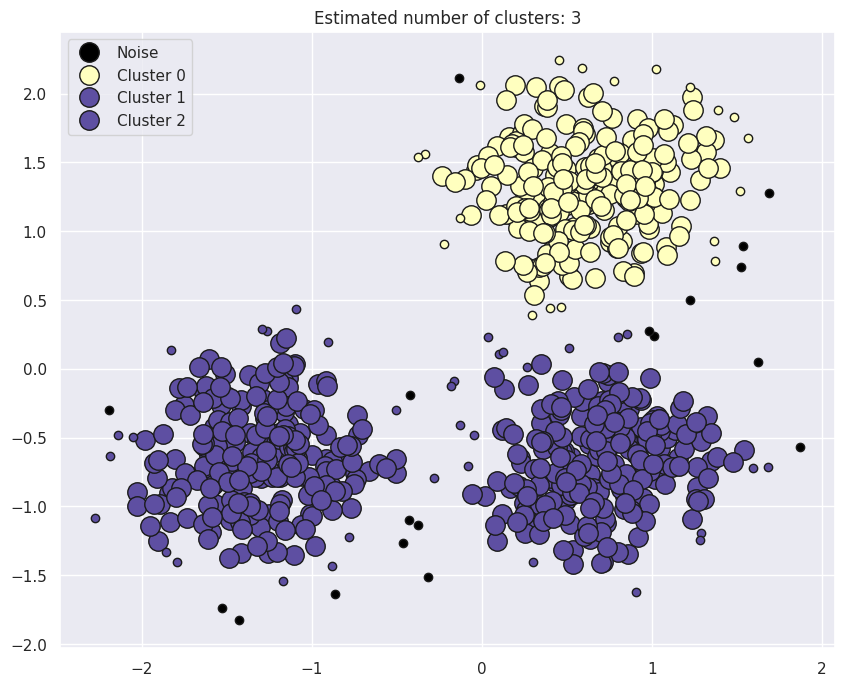

In [48]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

plt.figure(figsize=(10, 8))

noise_color = [0, 0, 0, 1]

num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

cmap = plt.cm.get_cmap('Spectral', num_clusters)

for i, k in enumerate(sorted(list(unique_labels))):
    if k == -1:
        col = noise_color
        label_text = 'Noise'
    else:
        col = cmap(float(i) / (num_clusters - 1)) if num_clusters > 1 else cmap(0.5)
        label_text = f'Cluster {k}'

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
        label=label_text
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.legend()
plt.show()

**Tugas Praktikum**

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [50]:
df = pd.read_csv('/content/Mall_Customers.csv')

print("Ukuran dataset:", df.shape)
display(df.head())

Ukuran dataset: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [51]:
print("Informasi dataset:")
df.info()

print("\nMissing value:")
print(df.isnull().sum())

print("\nStatistik deskriptif:")
display(df.describe())

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing value:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistik deskriptif:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [52]:
features = ['Annual Income (k$)', 'Spending Score (1-100)']

X = df[features]

print("Fitur yang digunakan:")
display(X.head())

Fitur yang digunakan:


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


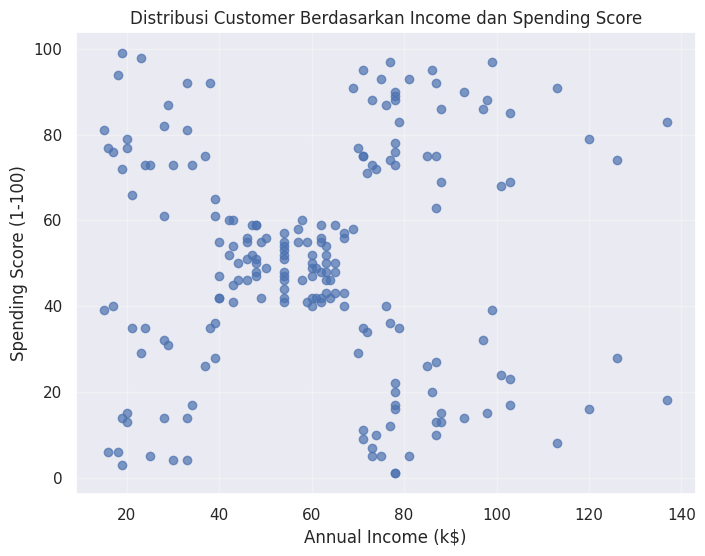

In [53]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    alpha=0.7
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Distribusi Customer Berdasarkan Income dan Spending Score')
plt.grid(alpha=0.3)
plt.show()

In [54]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data setelah normalisasi:")
print(X_scaled[:5])

Data setelah normalisasi:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


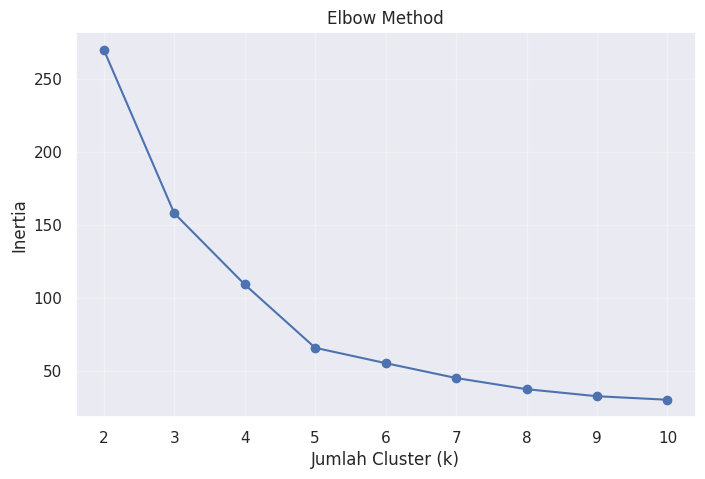

In [55]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(K_range)
plt.grid(alpha=0.3)

plt.show()

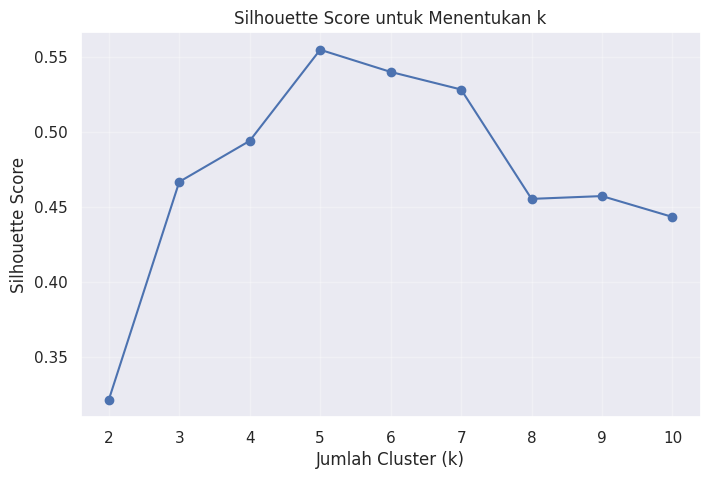

In [56]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(K_range, silhouette_scores, marker='o')

plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Menentukan k')
plt.xticks(K_range)
plt.grid(alpha=0.3)

plt.show()

In [57]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Jumlah customer pada setiap cluster:")
print(df['Cluster'].value_counts().sort_index())

Jumlah customer pada setiap cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


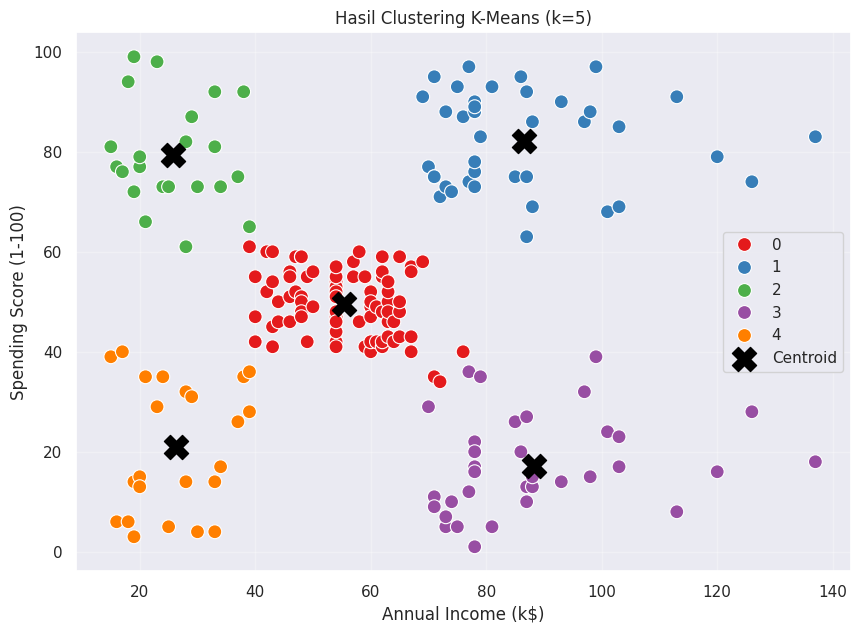

In [58]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

# Kembalikan posisi centroid dari skala normalisasi ke skala asli
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=300,
    c='black',
    label='Centroid'
)

plt.title('Hasil Clustering K-Means (k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [59]:
cluster_summary = df.groupby('Cluster')[features].mean().round(2)

display(cluster_summary)

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.30,49.52
1,86.54,82.13
2,25.73,79.36
3,88.20,17.11
4,26.30,20.91


In [60]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

from sklearn.metrics import (
    homogeneity_score,
    completeness_score,
    v_measure_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    silhouette_score
)

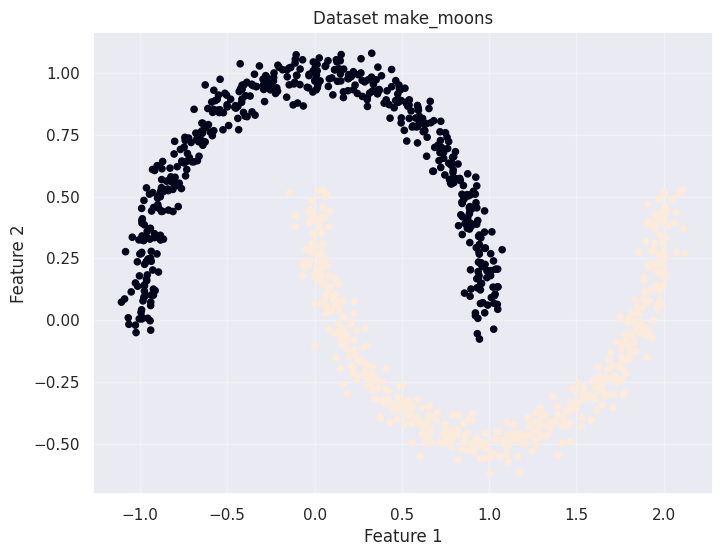

In [61]:
X_moons, y_true = make_moons(
    n_samples=1000,
    noise=0.05,
    random_state=42
)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_moons[:, 0],
    X_moons[:, 1],
    c=y_true,
    s=20
)

plt.title('Dataset make_moons')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(alpha=0.3)

plt.show()

In [62]:
scaler_moons = StandardScaler()

X_moons_scaled = scaler_moons.fit_transform(X_moons)

print("Data sebelum normalisasi:")
print(X_moons[:5])

print("\nData setelah normalisasi:")
print(X_moons_scaled[:5])

Data sebelum normalisasi:
[[-0.02137124  0.40618608]
 [ 0.97670045 -0.45832306]
 [ 0.90405882 -0.37651952]
 [ 0.37736316 -0.39703717]
 [-0.84192557  0.53058695]]

Data setelah normalisasi:
[[-0.59996716  0.31757343]
 [ 0.55020965 -1.42528284]
 [ 0.46649751 -1.26036633]
 [-0.14046604 -1.30173005]
 [-1.54557314  0.56836644]]


In [63]:
dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

labels = dbscan.fit_predict(X_moons_scaled)

# Jumlah cluster, tidak termasuk noise (-1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Jumlah noise
n_noise = np.sum(labels == -1)

print("Jumlah cluster:", n_clusters)
print("Jumlah noise:", n_noise)

Jumlah cluster: 2
Jumlah noise: 0


In [64]:
homogeneity = homogeneity_score(y_true, labels)
completeness = completeness_score(y_true, labels)
v_measure = v_measure_score(y_true, labels)
ari = adjusted_rand_score(y_true, labels)
ami = adjusted_mutual_info_score(y_true, labels)

# Silhouette dihitung terhadap seluruh hasil clustering
silhouette = silhouette_score(X_moons_scaled, labels)

print(f"Homogeneity : {homogeneity:.4f}")
print(f"Completeness: {completeness:.4f}")
print(f"V-measure   : {v_measure:.4f}")
print(f"ARI         : {ari:.4f}")
print(f"AMI         : {ami:.4f}")
print(f"Silhouette  : {silhouette:.4f}")

Homogeneity : 1.0000
Completeness: 1.0000
V-measure   : 1.0000
ARI         : 1.0000
AMI         : 1.0000
Silhouette  : 0.3912


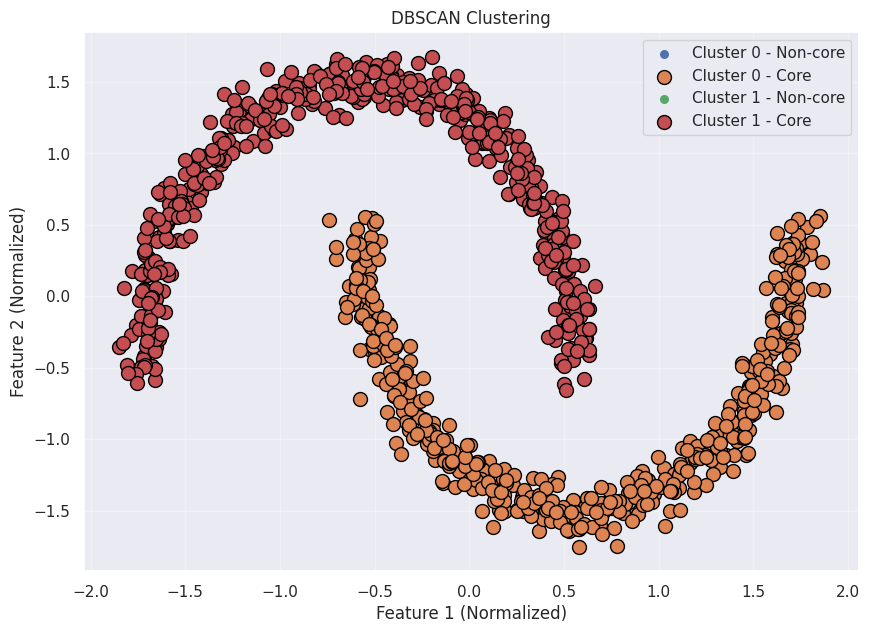

In [65]:
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

plt.figure(figsize=(10, 7))

unique_labels = sorted(set(labels))

for cluster_label in unique_labels:

    # Noise
    if cluster_label == -1:
        color = 'black'
        cluster_mask = labels == cluster_label

        plt.scatter(
            X_moons_scaled[cluster_mask, 0],
            X_moons_scaled[cluster_mask, 1],
            c=color,
            s=30,
            label='Noise'
        )

    else:
        cluster_mask = labels == cluster_label

        # Non-core points
        non_core_mask = cluster_mask & ~core_samples_mask

        plt.scatter(
            X_moons_scaled[non_core_mask, 0],
            X_moons_scaled[non_core_mask, 1],
            s=30,
            label=f'Cluster {cluster_label} - Non-core'
        )

        # Core points
        core_mask = cluster_mask & core_samples_mask

        plt.scatter(
            X_moons_scaled[core_mask, 0],
            X_moons_scaled[core_mask, 1],
            s=100,
            edgecolors='black',
            label=f'Cluster {cluster_label} - Core'
        )

plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1 (Normalized)')
plt.ylabel('Feature 2 (Normalized)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [66]:
def evaluate_dbscan(eps, min_samples):

    model = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = model.fit_predict(X_moons_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    homogeneity = homogeneity_score(y_true, labels)
    completeness = completeness_score(y_true, labels)
    v_measure = v_measure_score(y_true, labels)
    ari = adjusted_rand_score(y_true, labels)
    ami = adjusted_mutual_info_score(y_true, labels)

    # Silhouette hanya dihitung jika ada minimal 2 cluster
    non_noise_mask = labels != -1

    if (
        n_clusters >= 2
        and len(set(labels[non_noise_mask])) >= 2
    ):
        silhouette = silhouette_score(
            X_moons_scaled[non_noise_mask],
            labels[non_noise_mask]
        )
    else:
        silhouette = np.nan

    return {
        'eps': eps,
        'min_samples': min_samples,
        'clusters': n_clusters,
        'noise': n_noise,
        'homogeneity': homogeneity,
        'completeness': completeness,
        'v_measure': v_measure,
        'ARI': ari,
        'AMI': ami,
        'silhouette': silhouette
    }

In [67]:
eps_values = [0.05, 0.1, 0.2, 0.3, 0.5]
min_samples_values = [3, 10, 20]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        result = evaluate_dbscan(
            eps=eps,
            min_samples=min_samples
        )

        results.append(result)

results_df = pd.DataFrame(results)

display(
    results_df.round(4)
)

,eps,min_samples,clusters,noise,homogeneity,completeness,v_measure,ARI,AMI,silhouette
0,0.05,3,69,186,0.8156,0.1525,0.2570,0.0300,0.2438,0.3492
1,0.05,10,3,970,0.0307,0.1268,0.0494,0.0023,0.0459,0.8807
2,0.05,20,0,1000,0.0000,1.0000,0.0000,0.0000,0.0000,NaN
3,0.10,3,2,14,0.9862,0.9029,0.9427,0.9722,0.9426,0.3939
4,0.10,10,7,57,0.9433,0.4095,0.5711,0.5234,0.5698,0.2097
5,0.10,20,6,850,0.1539,0.1555,0.1547,0.0168,0.1509,0.7873
6,0.20,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
7,0.20,10,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
8,0.20,20,2,3,1.0000,0.9742,0.9869,0.9940,0.9869,0.3953
9,0.30,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912


In [68]:
results_df.round(4)

,eps,min_samples,clusters,noise,homogeneity,completeness,v_measure,ARI,AMI,silhouette
0,0.05,3,69,186,0.8156,0.1525,0.2570,0.0300,0.2438,0.3492
1,0.05,10,3,970,0.0307,0.1268,0.0494,0.0023,0.0459,0.8807
2,0.05,20,0,1000,0.0000,1.0000,0.0000,0.0000,0.0000,NaN
3,0.10,3,2,14,0.9862,0.9029,0.9427,0.9722,0.9426,0.3939
4,0.10,10,7,57,0.9433,0.4095,0.5711,0.5234,0.5698,0.2097
5,0.10,20,6,850,0.1539,0.1555,0.1547,0.0168,0.1509,0.7873
6,0.20,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
7,0.20,10,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
8,0.20,20,2,3,1.0000,0.9742,0.9869,0.9940,0.9869,0.3953
9,0.30,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912


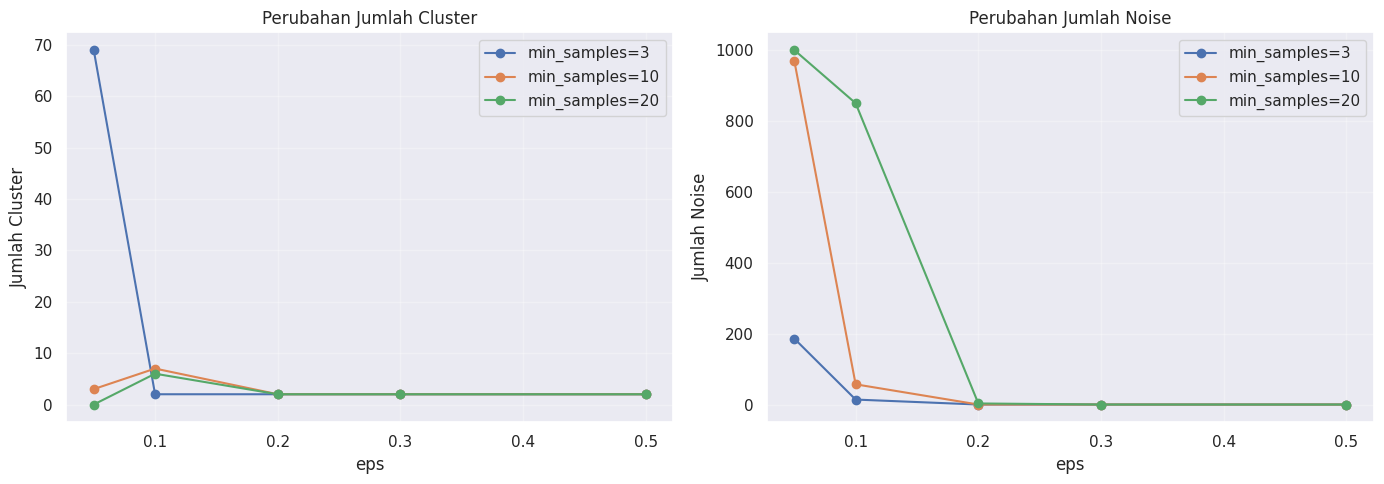

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Jumlah cluster
for ms in min_samples_values:
    subset = results_df[results_df['min_samples'] == ms]

    axes[0].plot(
        subset['eps'],
        subset['clusters'],
        marker='o',
        label=f'min_samples={ms}'
    )

axes[0].set_title('Perubahan Jumlah Cluster')
axes[0].set_xlabel('eps')
axes[0].set_ylabel('Jumlah Cluster')
axes[0].legend()
axes[0].grid(alpha=0.3)


# Jumlah noise
for ms in min_samples_values:
    subset = results_df[results_df['min_samples'] == ms]

    axes[1].plot(
        subset['eps'],
        subset['noise'],
        marker='o',
        label=f'min_samples={ms}'
    )

axes[1].set_title('Perubahan Jumlah Noise')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('Jumlah Noise')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

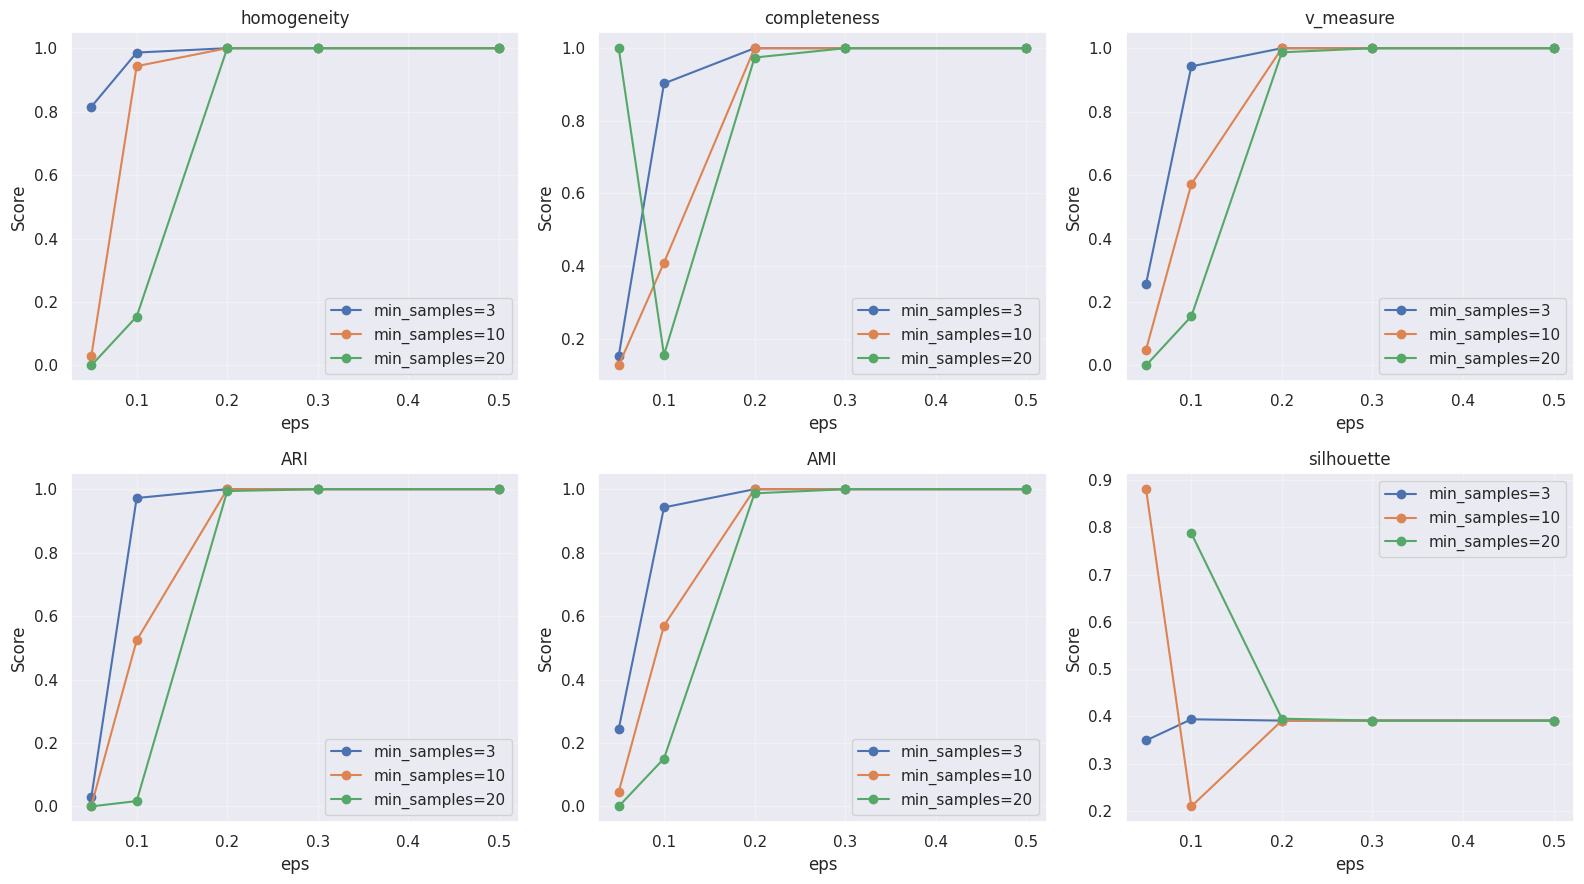

In [70]:
metrics = [
    'homogeneity',
    'completeness',
    'v_measure',
    'ARI',
    'AMI',
    'silhouette'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, metric in zip(axes.flatten(), metrics):

    for ms in min_samples_values:

        subset = results_df[
            results_df['min_samples'] == ms
        ]

        ax.plot(
            subset['eps'],
            subset[metric],
            marker='o',
            label=f'min_samples={ms}'
        )

    ax.set_title(metric)
    ax.set_xlabel('eps')
    ax.set_ylabel('Score')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()